# Med Center Shuttle Peak Hours Analysis and Recommendations

This notebook will analyze the APC ridership data to assist in optimizing bus deployment across the med center express shuttle. The analysis will use BusState files from January 1, 2026 - April 17, 2026. 

### Directions

**Inbound:** Carmack 2, 3, 5A and 5B -> University Hospital, Doan Hall

**Outbound:** University Hospital, Doan Hall -> Carmack 2, 3, 5A and 5B

### Key Variables Used
- STOP_ID:      The ID of the stop (401, 403, 404, 94, 95, 401, 37)
- ARRIVAL:      Arrival time of the bus at the current stop
- DEPARTURE:    Departure time of the bus at the current stop
- BOARDINGS:    Number of boardings detected by APC at the current stop 
- ALIGHTINGS:   Number of alightings detected by APC at the current stop
- HOUR:         Hour of event
- MINUTE:       Minute of event
- DATE:         Date of event

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Global config for analysis and viz

# boilerplate for all viz
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.grid':        True,
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

# seaborn styles set
sns.set_style("whitegrid", {
    'axes.facecolor': '#F8F8F6',
    'grid.color':       '#E0DED8',
    'grid.linewidth':   0.6,
})

# stop id and names
STOP_NAMES = {
    37: 'Doan Hall',
    94: 'Carmack 5A',
    95: 'Carmack 5B',
    401: 'University Hospital',
    403: 'Carmack 2',
    404: 'Carmack 3'
}

# bus max capacity
# based on previous analysis, 65 is generally considered the max capacity for a cabs bus
BUS_CAPACITY = 65
CARMACK_5_BEGINS = 7 # busses stop at carmack 5 starting after 7am according to run books


---

## Loading and Validation of Data

In [2]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

data_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours"
# going to have to rework the process_mc_busstate function to take in new dir

# month and date dict
timeframe_dict = {
    # 'JAN': 2026,
    # 'FEB': 2026,
    'MAR': 2026,
    'APR': 2026
}
# set dir to save cleaned files to 
repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

# loop through and concat to once single df
df = pd.DataFrame()
for month, year in timeframe_dict.items():
    df = pd.concat([df, mcd.process_mc_busstate(year=year, month=month, current_dir=data_dir, repo_dir=repo_dir)], ignore_index=True)

# This should only have to be run once per session. ~9 minutes to run

In [40]:
# Cut down df to necessary columns
mc_df = df[['DATE', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS', 'RUN_ID', 'ARRIVAL', 'DEPARTURE', 'DWELL', 'HOUR', 'MINUTE']].copy()
mc_df.columns = mc_df.columns.str.lower()

# Parse and filter timeframe 3/1/2026 - 4/14/2026
mc_df['date'] = pd.to_datetime(mc_df['date'])
mc_df = mc_df[(mc_df['date'] >= '2026-03-01') & (mc_df['date'] <= '2026-04-14')]

# Parse time-related columns
mc_df['arrival'] = pd.to_datetime(mc_df['arrival'])
mc_df['departure'] = pd.to_datetime(mc_df['departure'])
mc_df['dwell'] = pd.to_timedelta(mc_df['dwell'], unit='s')
mc_df['time'] = pd.to_datetime(mc_df['date'].astype(str) + ' ' + mc_df['arrival'].dt.time.astype(str))

mc_df.sort_values(by='time', inplace=True)

# Normalize numeric dtypes
mc_df['stop_id'] = mc_df['stop_id'].astype(int)
mc_df['boardings'] = mc_df['boardings'].astype(int)
mc_df['alightings'] = mc_df['alightings'].astype(int)
mc_df['run_id'] = mc_df['run_id'].astype(int)

# Add convenience columns
mc_df['stop_name'] = mc_df['stop_id'].map(STOP_NAMES)
mc_df['weekday'] = mc_df['date'].dt.day_name()  # in case weekday-related patterns surface
mc_df['dwell_sec'] = mc_df['dwell'].dt.total_seconds()

# Remove weekend rows currently out of scope
mc_df = mc_df[mc_df['weekday'] != 'Saturday']

In [41]:
# Shape and data check
print(f'Records : {len(mc_df)}')
print(f'Date range : {mc_df["date"].min().date()}  - {mc_df["date"].max().date()}')
print(f'Unique dates : {mc_df["date"].dt.date.nunique()}')
print(mc_df.dtypes)
mc_df.head(3)

Records : 52727
Date range : 2026-03-02  - 2026-04-14
Unique dates : 32
date           datetime64[us]
stop_id                 int64
boardings               int64
alightings              int64
run_id                  int64
arrival        datetime64[us]
departure      datetime64[us]
dwell         timedelta64[us]
hour                    int32
minute                  int32
time           datetime64[us]
stop_name                 str
weekday                   str
dwell_sec             float64
dtype: object


,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec
16770,2026-03-02,403,0,0,1502,1900-01-01 00:22:07,1900-01-01 00:22:32,0 days 00:00:25,0,22,2026-03-02 00:22:07,Carmack 2,Monday,25.0
16771,2026-03-02,404,0,0,1502,1900-01-01 00:23:10,1900-01-01 00:23:35,0 days 00:00:25,0,23,2026-03-02 00:23:10,Carmack 3,Monday,25.0
16772,2026-03-02,94,0,0,1502,1900-01-01 00:24:19,1900-01-01 00:24:26,0 days 00:00:07,0,24,2026-03-02 00:24:19,Carmack 5A,Monday,7.0


In [42]:
# Missing data check
missing = mc_df.isnull().sum()
missing

date          0
stop_id       0
boardings     0
alightings    0
run_id        0
arrival       0
departure     0
dwell         0
hour          0
minute        0
time          0
stop_name     0
weekday       0
dwell_sec     0
dtype: int64

In [43]:
# Data ranges and distributions check
mc_df.describe()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,dwell_sec
count,52727,52727.000000,52727.000000,52727.000000,52727.000000,52727,52727,52727,52727.000000,52727.000000,52727,52727.000000
mean,2026-03-22 15:47:30.600261,247.134675,3.529292,3.442790,1504.337929,1900-01-01 13:18:31.265879,1900-01-01 13:19:41.596924,0 days 00:01:10.331044,12.813758,29.208489,2026-03-23 05:06:01.866140,70.331045
min,2026-03-02 00:00:00,37.000000,0.000000,0.000000,1501.000000,1900-01-01 00:00:00,1900-01-01 00:00:06,0 days 00:00:00,0.000000,0.000000,2026-03-02 00:22:07,0.000000
25%,2026-03-11 00:00:00,94.000000,0.000000,0.000000,1502.000000,1900-01-01 07:35:31.500000,1900-01-01 07:36:48.500000,0 days 00:00:36,7.000000,14.000000,2026-03-11 18:29:05.500000,36.000000
50%,2026-03-23 00:00:00,401.000000,1.000000,1.000000,1504.000000,1900-01-01 14:13:35,1900-01-01 14:15:02,0 days 00:00:53,14.000000,29.000000,2026-03-23 11:02:10,53.000000
75%,2026-04-03 00:00:00,403.000000,5.000000,5.000000,1506.000000,1900-01-01 18:25:54.500000,1900-01-01 18:27:25.500000,0 days 00:01:27,18.000000,44.000000,2026-04-03 06:56:39.500000,87.000000
max,2026-04-14 00:00:00,404.000000,53.000000,47.000000,1514.000000,1900-01-01 23:59:58,1900-01-01 23:59:59,0 days 00:22:43,23.000000,59.000000,2026-04-14 23:57:09,1363.000000
std,NaN,165.670728,5.634727,5.326048,2.879902,NaN,NaN,0 days 00:00:54.197576,6.117385,17.492716,NaN,54.197576



---
## Analysis and Visualization of the Data
**Notes:**
- mc_df denotes the dataframe with the busstate data for the sample of 3/1/2026 - 4/14/2026
- The sample timeframe of 3/1/2026 - 4/14/2026 was chosen due to the new hospital tower opening in late February 2026
    - This should give the best possible view of staffing and demand changes to the shuttle


---

## Key Metrics Summary

In [68]:
# Aggregate to hourly totals
hourly_mc_df = (
    mc_df.groupby('hour')
    .agg(
        total_boardings=('boardings', 'sum'),
        total_alightings=('alightings', 'sum'),
        avg_dwell_sec=('dwell_sec', 'mean')
    )
    .reset_index()
)

# Sanity check of total boardings and alightings
total_boardings = hourly_mc_df['total_boardings'].sum()
total_alightings = hourly_mc_df['total_alightings'].sum()

# Total number of each within 5000
e = total_boardings - total_alightings
print(f'Total boardings: {total_boardings}')
print(f'Total alightings: {total_alightings}')
print(f'Difference: {e}')
# The total boardings and alightings should theoretically be the same
# The difference is likely due to APC data collection error
# Given the large sample size, this small difference should not significantly impact the overall analysis
# Approximately 2.5% difference.

Total boardings: 186089
Total alightings: 181528
Difference: 4561


In [69]:
# summary stats
peak_hour   = hourly_mc_df.loc[hourly_mc_df['total_boardings'].idxmax(), 'hour']
peak_vol    = hourly_mc_df['total_boardings'].max()
avg_dwell   = hourly_mc_df['avg_dwell_sec'].mean()

peak_hour, peak_vol, avg_dwell

(np.int32(6), np.int64(23905), np.float64(69.32903473422972))

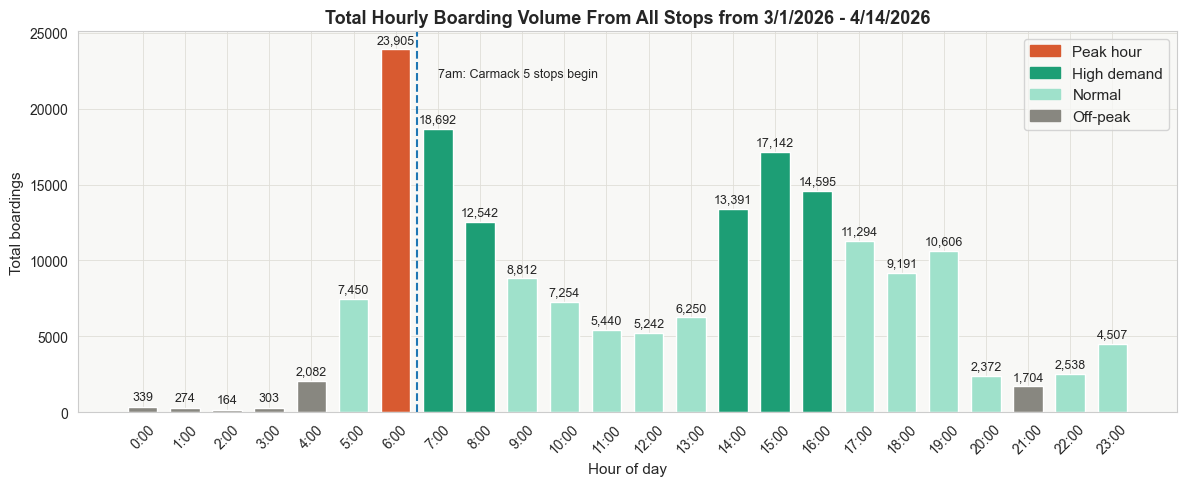

Q1 (25th percentile): 2299.5
Q3 (75th percentile): 11606.0


In [ ]:
# Starting at 7am the busses will stop at the carmack stops too.

# define the quartiles for boardings for color coding
q1 = hourly_mc_df['total_boardings'].quantile(0.25)
q3 = hourly_mc_df['total_boardings'].quantile(0.75)

# plot the hourly boardings accross all stops to get a sense of overall traffic

TEAL   = '#1D9E75'       # high demand
GRAY   = '#888780'       # off-peak
CORAL  = '#D85A30'       # peak hour
LIGHT_TEAL   = '#9FE1CB' # 'normal' demand

fig, ax = plt.subplots(figsize=(12, 5))

# define colors for each demand level
def get_color(hour, boardings):
    if hour == peak_hour:
        return CORAL # peak capacity hour
    elif (boardings ) >= q3: # high demand
        return TEAL
    elif boardings <= q1: # low demand
        return GRAY
    return LIGHT_TEAL # normal

colors = [
    get_color(h, b)
    for h, b in zip(hourly_mc_df['hour'], hourly_mc_df['total_boardings'])
]

# x = hour, y =total boardings, color coded by demand
bars = ax.bar(
    hourly_mc_df['hour'],
    hourly_mc_df['total_boardings'],
    color=colors,
    width=0.7
)

# add the value to each bar
max_val = hourly_mc_df['total_boardings'].max()
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max_val * 0.01,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# mark time when carmack 5 stops start
ax.axvline(CARMACK_5_BEGINS - 0.5, linestyle='--', linewidth=1.5)

ax.text(
    CARMACK_5_BEGINS,
    max_val * 0.95,
    '7am: Carmack 5 stops begin',
    fontsize=9,
    va='top'
)

# legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Peak hour'),
    mpatches.Patch(color=TEAL, label='High demand'),
    mpatches.Patch(color=LIGHT_TEAL, label='Normal'),
    mpatches.Patch(color=GRAY, label='Off-peak')
])

# format axes
ax.set(
    xticks=hourly_mc_df['hour'],
    xticklabels=[f'{h}:00' for h in hourly_mc_df['hour']],
    xlabel='Hour of day',
    ylabel='Total boardings',
    title='Total Hourly Boarding Volume From All Stops from 3/1/2026 - 4/14/2026'
)
# make easier to see
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Lower Threshold (25th percentile): {q1}')
print(f'Upper Threshold (75th percentile): {q3}')

np.int64(186089)